# Trabalho Final - Sistemas Inteligentes
---

## ETAPA 1 — Setup e Carregamento

In [1]:
!pip install ucimlrepo -q

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Carregar dataset TCGA Glioma
base = fetch_ucirepo(id=759)
X = base.data.features.copy()
y = base.data.targets.copy()

print(f'Dataset carregado com sucesso!')
print(f'Instâncias: {X.shape[0]}  |  Atributos: {X.shape[1]}')

Dataset carregado com sucesso!
Instâncias: 839  |  Atributos: 23


### Exploração Inicial

In [3]:
# Quantidade de instâncias e atributos
print(f'Shape: {X.shape}')
print(f'\n--- Tipos de dados ---')
print(X.dtypes)
print(f'\n--- Valores ausentes por coluna ---')
print(X.isnull().sum())
print(f'\nTotal de valores ausentes: {X.isnull().sum().sum()}')
print(f'\n--- Duplicatas ---')
print(f'Registros duplicados: {X.duplicated().sum()}')

Shape: (839, 23)

--- Tipos de dados ---
Gender                int64
Age_at_diagnosis    float64
Race                    str
IDH1                  int64
TP53                  int64
ATRX                  int64
PTEN                  int64
EGFR                  int64
CIC                   int64
MUC16                 int64
PIK3CA                int64
NF1                   int64
PIK3R1                int64
FUBP1                 int64
RB1                   int64
NOTCH1                int64
BCOR                  int64
CSMD3                 int64
SMARCA4               int64
GRIN2A                int64
IDH2                  int64
FAT4                  int64
PDGFRA                int64
dtype: object

--- Valores ausentes por coluna ---
Gender              0
Age_at_diagnosis    0
Race                0
IDH1                0
TP53                0
ATRX                0
PTEN                0
EGFR                0
CIC                 0
MUC16               0
PIK3CA              0
NF1                 0


In [4]:
# Distribuição das classes (0=LGG, 1=GBM)
print('--- Distribuição das classes ---')
print(y['Grade'].value_counts())
print()
print(y['Grade'].value_counts(normalize=True))

--- Distribuição das classes ---
Grade
0    487
1    352
Name: count, dtype: int64

Grade
0    0.580453
1    0.419547
Name: proportion, dtype: float64


---

## ETAPA 2 — Pré-processamento

In [5]:
# Converter Age_at_diagnosis para numérico, se necessário
X['Age_at_diagnosis'] = pd.to_numeric(X['Age_at_diagnosis'], errors='coerce')

# Remover registros com valores ausentes
registros_antes = len(X)
mascara = X.notna().all(axis=1) & y['Grade'].notna()
X = X[mascara].reset_index(drop=True)
y = y[mascara].reset_index(drop=True)
registros_depois = len(X)

print(f'Registros antes: {registros_antes}')
print(f'Registros removidos: {registros_antes - registros_depois}')
print(f'Registros restantes: {registros_depois}')

Registros antes: 839
Registros removidos: 0
Registros restantes: 839


In [6]:
# Definição das colunas
colunas_continuas = ['Age_at_diagnosis']
colunas_categoricas = ['Gender', 'Race']
colunas_binarias = [
    col for col in X.columns
    if col not in colunas_continuas + colunas_categoricas
]

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('continuas', StandardScaler(), colunas_continuas),
        ('categoricas', OneHotEncoder(drop='first', handle_unknown='ignore',
                                       sparse_output=False), colunas_categoricas),
        ('binarias', 'passthrough', colunas_binarias)
    ]
)

---
## ETAPA 3 — Divisão dos Dados

In [7]:
from sklearn.model_selection import train_test_split, StratifiedKFold

X_train, X_test, y_train, y_test = train_test_split(
    X, y['Grade'], test_size=0.30, stratify=y['Grade'], random_state=42
)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Treino: {len(X_train)}  |  Teste: {len(X_test)}')
print(f'\nDistribuição no treino:\n{y_train.value_counts()}')
print(f'\nDistribuição no teste:\n{y_test.value_counts()}')

Treino: 587  |  Teste: 252

Distribuição no treino:
Grade
0    341
1    246
Name: count, dtype: int64

Distribuição no teste:
Grade
0    146
1    106
Name: count, dtype: int64


---
## ETAPA 4 — Implementação dos Modelos

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import BernoulliNB

# pos_label é 1 para a classe GBM
f1_gbm_scorer = make_scorer(f1_score, pos_label=1)

def executar_modelo(modelo, params, nome):
    pipeline = Pipeline([
        ('preprocessamento', preprocessor),
        ('modelo', modelo)
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=params,
        cv=kfold,
        scoring=f1_gbm_scorer,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    print(f'\n=== {nome} ===')
    print(f'Melhores parâmetros: {grid.best_params_}')
    print(f'Melhor F1 (CV): {grid.best_score_:.4f}')

    return grid.best_estimator_

In [9]:
# --- KNN ---
params_knn = {
    'modelo__n_neighbors': [3, 5, 7, 9, 11],
    'modelo__weights': ['uniform', 'distance'],
    'modelo__metric': ['euclidean', 'manhattan', 'hamming']
}
modelo_knn = executar_modelo(KNeighborsClassifier(), params_knn, 'KNN')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

=== KNN ===
Melhores parâmetros: {'modelo__metric': 'manhattan', 'modelo__n_neighbors': 11, 'modelo__weights': 'uniform'}
Melhor F1 (CV): 0.8441


In [10]:
# --- MLP ---
params_mlp = {
    'modelo__hidden_layer_sizes': [(32,), (64,), (32, 16), (64, 32)],
    'modelo__activation': ['relu', 'tanh'],
    'modelo__solver': ['adam', 'lbfgs'],
    'modelo__alpha': [0.0001, 0.001, 0.01],
    'modelo__learning_rate': ['constant', 'adaptive']
}
mlp = MLPClassifier(random_state=42, early_stopping=True, max_iter=500)
modelo_mlp = executar_modelo(mlp, params_mlp, 'MLP')

Fitting 5 folds for each of 96 candidates, totalling 480 fits

=== MLP ===
Melhores parâmetros: {'modelo__activation': 'tanh', 'modelo__alpha': 0.0001, 'modelo__hidden_layer_sizes': (64, 32), 'modelo__learning_rate': 'constant', 'modelo__solver': 'adam'}
Melhor F1 (CV): 0.8033


In [11]:
# --- BernoulliNB ---
params_bernoulli = {
    'modelo__alpha': [1e-9, 1e-3, 0.1, 0.5, 1.0],
    'modelo__binarize': [None, 0.0, 0.5],
    'modelo__fit_prior': [True, False]
}
modelo_nb = executar_modelo(BernoulliNB(), params_bernoulli, 'BernoulliNB')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

=== BernoulliNB ===
Melhores parâmetros: {'modelo__alpha': 1.0, 'modelo__binarize': 0.5, 'modelo__fit_prior': False}
Melhor F1 (CV): 0.8598


---
## ETAPA 5 — Métricas de Avaliação

In [12]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, cohen_kappa_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)

def avaliar_modelo(modelo, X_teste, y_teste, nome):
    y_pred = modelo.predict(X_teste)
    
    # A classe GBM (1) 
    classes = list(modelo.classes_)
    idx_gbm = classes.index(1) # <<--- CORREÇÃO AQUI (era 'GBM', agora é 1)
    y_proba = modelo.predict_proba(X_teste)[:, idx_gbm]

    print(f'\n=== {nome} ===')
    print('Acurácia:', accuracy_score(y_teste, y_pred))
    print('Precisão:', precision_score(y_teste, y_pred, pos_label=1))
    print('Recall:', recall_score(y_teste, y_pred, pos_label=1))
    print('F1:', f1_score(y_teste, y_pred, pos_label=1))
    print('Kappa:', cohen_kappa_score(y_teste, y_pred))
    print('AUC:', roc_auc_score(y_teste, y_proba))

    # Matriz de confusão
    cm = confusion_matrix(y_teste, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['LGG (0)', 'GBM (1)'])
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de Confusão — {nome}')
    plt.show()

    return y_pred, y_proba


=== KNN ===
Acurácia: 0.873015873015873
Precisão: 0.8245614035087719
Recall: 0.8867924528301887
F1: 0.8545454545454545
Kappa: 0.7421335379892555
AUC: 0.9037542000516929


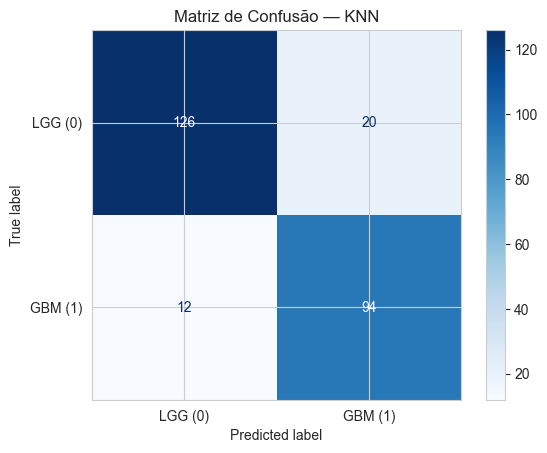


=== MLP ===
Acurácia: 0.8015873015873016
Precisão: 0.8333333333333334
Recall: 0.660377358490566
F1: 0.7368421052631579
Kappa: 0.5810055865921788
AUC: 0.8874386146291032


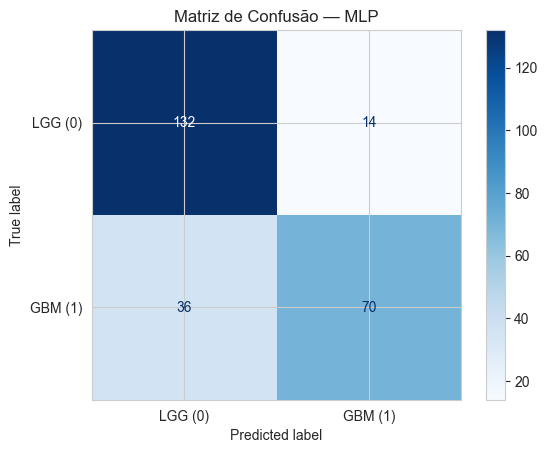


=== BernoulliNB ===
Acurácia: 0.8650793650793651
Precisão: 0.8
Recall: 0.9056603773584906
F1: 0.8495575221238938
Kappa: 0.7281035795887281
AUC: 0.9082773326440942


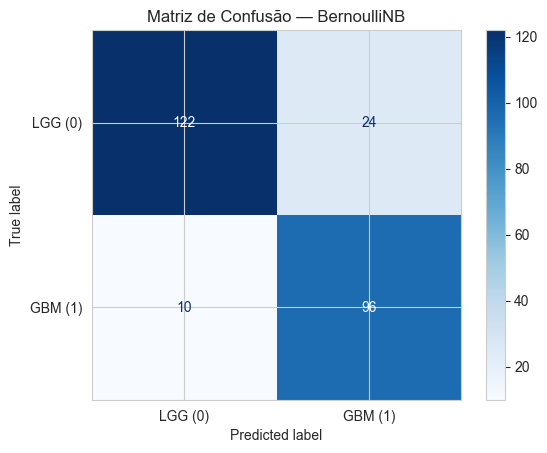

In [13]:
y_pred_knn, y_proba_knn = avaliar_modelo(modelo_knn, X_test, y_test, 'KNN')
y_pred_mlp, y_proba_mlp = avaliar_modelo(modelo_mlp, X_test, y_test, 'MLP')
y_pred_nb,  y_proba_nb  = avaliar_modelo(modelo_nb,  X_test, y_test, 'BernoulliNB')

In [14]:
def calcular_metricas(y_real, y_pred, y_proba):
    return {
        'Acurácia': accuracy_score(y_real, y_pred),
        'Precisão': precision_score(y_real, y_pred, pos_label=1),
        'Recall': recall_score(y_real, y_pred, pos_label=1),
        'F1': f1_score(y_real, y_pred, pos_label=1),
        'Kappa': cohen_kappa_score(y_real, y_pred),
        'AUC': roc_auc_score(y_real, y_proba),
    }

df_metricas = pd.DataFrame({
    'KNN': calcular_metricas(y_test, y_pred_knn, y_proba_knn),
    'MLP': calcular_metricas(y_test, y_pred_mlp, y_proba_mlp),
    'BernoulliNB': calcular_metricas(y_test, y_pred_nb, y_proba_nb),
}).round(4)

df_metricas

,KNN,MLP,BernoulliNB
Acurácia,0.8730,0.8016,0.8651
Precisão,0.8246,0.8333,0.8000
Recall,0.8868,0.6604,0.9057
F1,0.8545,0.7368,0.8496
Kappa,0.7421,0.5810,0.7281
AUC,0.9038,0.8874,0.9083


---
## ETAPA 6 — Análise de Erros

In [15]:
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

erros_knn = X_test_reset[y_pred_knn != y_test_reset.values].copy()
erros_mlp = X_test_reset[y_pred_mlp != y_test_reset.values].copy()
erros_nb  = X_test_reset[y_pred_nb  != y_test_reset.values].copy()

erros_knn['real'] = y_test_reset[y_pred_knn != y_test_reset.values].values
erros_knn['predito'] = y_pred_knn[y_pred_knn != y_test_reset.values]

erros_mlp['real'] = y_test_reset[y_pred_mlp != y_test_reset.values].values
erros_mlp['predito'] = y_pred_mlp[y_pred_mlp != y_test_reset.values]

erros_nb['real'] = y_test_reset[y_pred_nb != y_test_reset.values].values
erros_nb['predito'] = y_pred_nb[y_pred_nb != y_test_reset.values]

def analisar_erros(erros_df, nome):
    # Falsos Positivos (predito=1 (GBM), real=0 (LGG))
    fp = ((erros_df['predito'] == 1) & (erros_df['real'] == 0)).sum()
    # Falsos Negativos (predito=0 (LGG), real=1 (GBM))
    fn = ((erros_df['predito'] == 0) & (erros_df['real'] == 1)).sum()
    # Erros com IDH1 Wildtype
    erros_idh1_wt = (erros_df['IDH1'] == 0).sum()

    print(f'\n=== {nome} ===')
    print(f'  Total de Erros: {len(erros_df)}')
    print(f'  Falsos Positivos (pred GBM, real LGG): {fp}')
    print(f'  Falsos Negativos (pred LGG, real GBM): {fn}')
    print(f'  Erros com IDH1 Wildtype: {erros_idh1_wt}')

    for mut in ['IDH1', 'TP53', 'ATRX']:
        if len(erros_df) > 0:
            dist = erros_df[mut].value_counts(normalize=True).round(3)
            print(f'  Distribuição de {mut} nos erros: {dist.to_dict()}')

    return {
        'Modelo': nome,
        'Total de Erros': len(erros_df),
        'FP': fp,
        'FN': fn,
        'Erros com IDH1 Wildtype': erros_idh1_wt
    }

tabela_erros = [
    analisar_erros(erros_knn, 'KNN'),
    analisar_erros(erros_mlp, 'MLP'),
    analisar_erros(erros_nb, 'BernoulliNB'),
]

df_tabela_erros = pd.DataFrame(tabela_erros)
df_tabela_erros


=== KNN ===
  Total de Erros: 32
  Falsos Positivos (pred GBM, real LGG): 20
  Falsos Negativos (pred LGG, real GBM): 12
  Erros com IDH1 Wildtype: 23
  Distribuição de IDH1 nos erros: {0: 0.719, 1: 0.281}
  Distribuição de TP53 nos erros: {0: 0.562, 1: 0.438}
  Distribuição de ATRX nos erros: {0: 0.688, 1: 0.312}

=== MLP ===
  Total de Erros: 50
  Falsos Positivos (pred GBM, real LGG): 14
  Falsos Negativos (pred LGG, real GBM): 36
  Erros com IDH1 Wildtype: 40
  Distribuição de IDH1 nos erros: {0: 0.8, 1: 0.2}
  Distribuição de TP53 nos erros: {0: 0.64, 1: 0.36}
  Distribuição de ATRX nos erros: {0: 0.8, 1: 0.2}

=== BernoulliNB ===
  Total de Erros: 34
  Falsos Positivos (pred GBM, real LGG): 24
  Falsos Negativos (pred LGG, real GBM): 10
  Erros com IDH1 Wildtype: 25
  Distribuição de IDH1 nos erros: {0: 0.735, 1: 0.265}
  Distribuição de TP53 nos erros: {0: 0.618, 1: 0.382}
  Distribuição de ATRX nos erros: {0: 0.735, 1: 0.265}


,Modelo,Total de Erros,FP,FN,Erros com IDH1 Wildtype
0,KNN,32,20,12,23
1,MLP,50,14,36,40
2,BernoulliNB,34,24,10,25


---
## ETAPA 7 — Visualizações

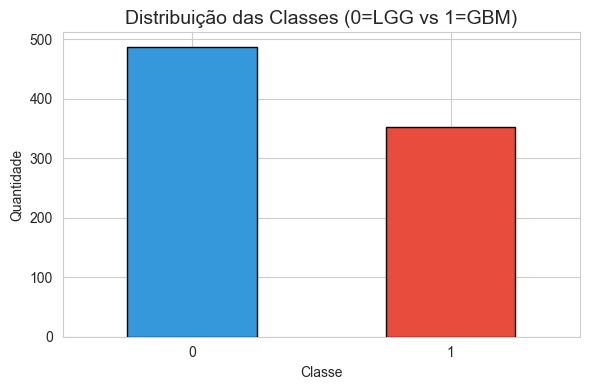

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
contagem = y['Grade'].value_counts()
contagem.plot(kind='bar', color=['#3498db', '#e74c3c'], ax=ax, edgecolor='black')
ax.set_title('Distribuição das Classes (0=LGG vs 1=GBM)', fontsize=14)
ax.set_ylabel('Quantidade')
ax.set_xlabel('Classe')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

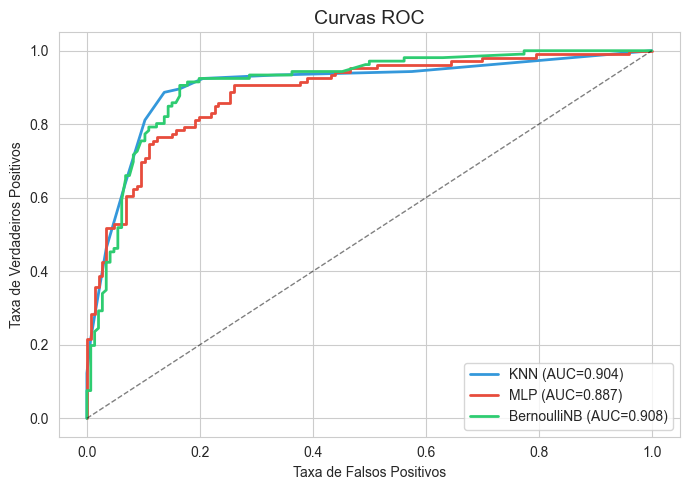

In [17]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 5))

modelos_proba = [
    ('KNN', y_proba_knn, '#3498db'),
    ('MLP', y_proba_mlp, '#e74c3c'),
    ('BernoulliNB', y_proba_nb, '#2ecc71')
]

for nome, y_proba, cor in modelos_proba:
    fpr, tpr, _ = roc_curve(y_test_reset, y_proba, pos_label=1)
    auc_val = roc_auc_score(y_test_reset, y_proba)
    ax.plot(fpr, tpr, label=f'{nome} (AUC={auc_val:.3f})', color=cor, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curvas ROC', fontsize=14)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

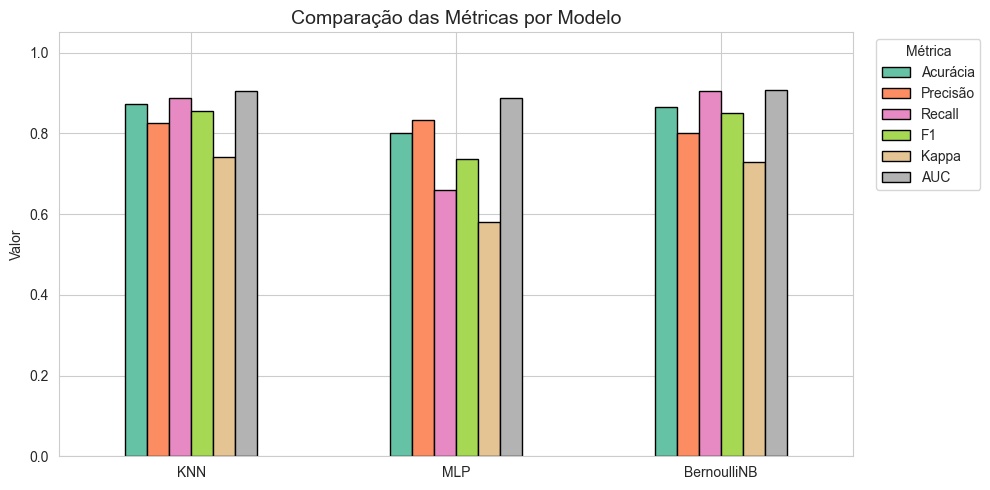

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
df_metricas.T.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black')
ax.set_title('Comparação das Métricas por Modelo', fontsize=14)
ax.set_ylabel('Valor')
ax.set_ylim(0, 1.05)
ax.legend(title='Métrica', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

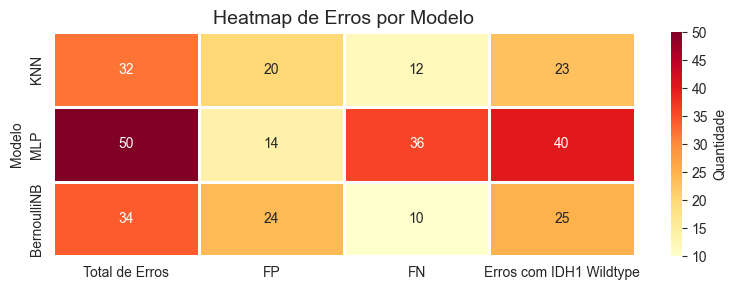

In [19]:
fig, ax = plt.subplots(figsize=(8, 3))
df_erros_plot = df_tabela_erros.set_index('Modelo')[[
    'Total de Erros', 'FP', 'FN', 'Erros com IDH1 Wildtype'
]].astype(float)
sns.heatmap(df_erros_plot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=1, cbar_kws={'label': 'Quantidade'})
ax.set_title('Heatmap de Erros por Modelo', fontsize=14)
plt.tight_layout()
plt.show()